In [1]:
import os
import sys
from pathlib import Path

library_path = os.path.abspath('../../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import chi2_contingency

from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score
import umap

DATA_PATH  = library_path.parent / 'data'
PLOTS_PATH = library_path.parent / 'plots'
PLOTS_PATH.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

## K-means Clustering and UMAP Visualisation

### Rationale

This notebook addresses **Aim 1**: characterising the subgroup structure of health and
sociodemographic heterogeneity across datasets, and identifying whether certain subgroups
are systematically under- or over-represented in DAPHNIE relative to HSE.

**K-means** partitions the covariate space into $k$ clusters based on Euclidean distance
in standardised feature space. The optimal $k$ is selected by silhouette score and the
elbow method on within-cluster sum of squares.

**UMAP** (Uniform Manifold Approximation and Projection) reduces the high-dimensional
covariate space to 2D for visual inspection. Unlike PCA, UMAP preserves local
neighbourhood structure, making cluster boundaries visible. Colour-coding by dataset
reveals whether DAPHNIE and HSE occupy different regions of the space.

### Feature set

The 17-variable predictor set from notebook 04 is used throughout (same variables as
the density ratio estimation). This ensures clusters are directly interpretable in terms
of the covariate shift already quantified.

### Design

- **Restricted sample:** DAPHNIE 2024 and HSE 2017–2018 only. The full 17-variable
  predictor set (including `resp`, `skin`, `paVig`, `paMod`) is complete only for this
  restricted pair; pooling additional datasets would require dropping these variables.
- Impute missing values (median strategy, primarily `meds_num`) and standardise
- Fit k-means for $k = 2, \ldots, 10$; select optimal $k$ via silhouette score (elbow as secondary check)
- Fit UMAP on the standardised features; colour by dataset, by cluster, and by EQ-5D index
- Profile each cluster: unweighted means per feature and per EQ-5D outcome
- Compute cluster composition by dataset (% of each dataset in each cluster)
- Link clusters to density ratio weights: re-estimate plain LR $w(x)$ and compute mean
  weight per cluster for DAPHNIE 2024 observations — clusters with $w > 1$ are
  underrepresented in DAPHNIE and upscaled by the norm derivation reweighting

In [3]:
df = pd.read_csv(DATA_PATH / 'wrangled_data.csv', low_memory=False)
print(f'Full dataset: {len(df):,} rows x {df.shape[1]} columns')
print(df['dataset'].value_counts().to_string())

Full dataset: 38,340 rows x 64 columns
dataset
HSE 2019        8026
HSE 2018        7990
HSE 2017        7840
HSE 2022        7590
DAPHNIE 2024    5237
DAPHNIE 2023    1657


In [4]:
# 17-variable predictor set (notebook 04)
EXTRA_FEATURES = [
    "paVig", "paMod", "resp", "skin",
]
BASE_FEATURES = [
    "Sex", "age7cat", "eth2cat", "emp_cat_Employed", "emp_cat_Other (Sick/Home/etc)", "emp_cat_Retired",
    "emp_cat_Student", "emp_cat_Unemployed", "edu_cat_2", "smoke_ecig", "diabetes",
    "meds_num", "ill_dis"
]
ALL_FEATURES = BASE_FEATURES + EXTRA_FEATURES
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]
print(f"Features ({len(ALL_FEATURES)}):")
print(ALL_FEATURES)

Features (17):
['Sex', 'age7cat', 'eth2cat', 'emp_cat_Employed', 'emp_cat_Other (Sick/Home/etc)', 'emp_cat_Retired', 'emp_cat_Student', 'emp_cat_Unemployed', 'edu_cat_2', 'smoke_ecig', 'diabetes', 'meds_num', 'ill_dis', 'paVig', 'paMod', 'resp', 'skin']


## 1. Data Preparation

In [5]:
KEEP_DATASETS = ['DAPHNIE 2024', 'HSE 2017', 'HSE 2018']
df_r = df[df['dataset'].isin(KEEP_DATASETS)].copy().reset_index(drop=True)

print('Restricted dataset:')
print(df_r['dataset'].value_counts().to_string())
print(f'\nTotal: {len(df_r):,} rows')

X_raw = df_r[ALL_FEATURES]
miss  = X_raw.isna().sum()
miss  = miss[miss > 0]
if len(miss):
    print('\nVariables with missing values:')
    print(miss.to_string())
else:
    print('\nNo missing values in feature set.')

imputer  = SimpleImputer(strategy='median')
scaler   = StandardScaler()
X_imp    = imputer.fit_transform(X_raw)
X_scaled = scaler.fit_transform(X_imp)
print(f'\nPreprocessed matrix: {X_scaled.shape} (rows x features)')

Restricted dataset:
dataset
HSE 2018        7990
HSE 2017        7840
DAPHNIE 2024    5237

Total: 21,067 rows

Variables with missing values:
Sex            45
age7cat        52
eth2cat        88
edu_cat_2     108
meds_num     6564
ill_dis       420
paVig        2500
paMod        2360

Preprocessed matrix: (21067, 17) (rows x features)


## 2. K-means: Cluster Selection ($k = 2$–$10$)

Inertia (within-cluster sum of squares) and silhouette score are computed for each $k$.
The silhouette score measures how well each observation fits its assigned cluster relative
to the nearest alternative cluster (range $-1$ to $1$; higher is better).
The elbow in inertia serves as a secondary check.

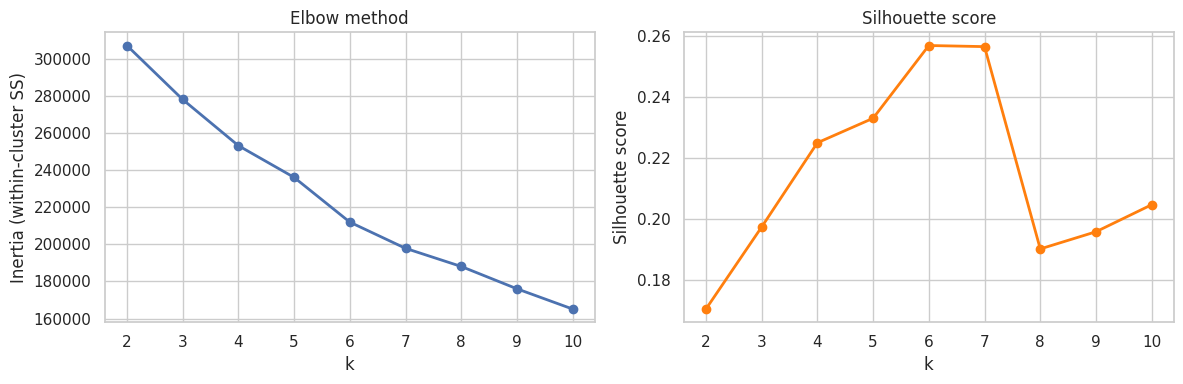

Silhouette scores: {2: 0.1704, 3: 0.1973, 4: 0.225, 5: 0.233, 6: 0.2569, 7: 0.2565, 8: 0.1901, 9: 0.1958, 10: 0.2047}
Selected k = 6  (peak silhouette = 0.2569)


In [6]:
K_RANGE = range(2, 11)
inertias, silhouettes = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, max_iter=300, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(
        silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_RANGE), inertias, marker='o', linewidth=2)
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia (within-cluster SS)')
axes[0].set_title('Elbow method')
axes[1].plot(list(K_RANGE), silhouettes, marker='o', linewidth=2, color='tab:orange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score')
plt.tight_layout()
plt.savefig(PLOTS_PATH / 'kmeans_selection.png', dpi=150, bbox_inches='tight')
plt.show()

K_OPT = list(K_RANGE)[int(np.argmax(silhouettes))]
print(f'Silhouette scores: {dict(zip(K_RANGE, [round(s, 4) for s in silhouettes]))}')
print(f'Selected k = {K_OPT}  (peak silhouette = {max(silhouettes):.4f})')

## 3. Final K-means Fit

In [7]:
km_final = KMeans(n_clusters=K_OPT, n_init=20, max_iter=300, random_state=42)
df_r['cluster'] = km_final.fit_predict(X_scaled)

sizes = df_r['cluster'].value_counts().sort_index()
print(f'Cluster sizes (k = {K_OPT}):')
print(sizes.to_string())
print(f'\nSmallest cluster: {sizes.min():,}  ({sizes.min() / len(df_r) * 100:.1f}% of total)')

Cluster sizes (k = 6):
cluster
0    11236
1     2413
2     5488
3      724
4      419
5      787

Smallest cluster: 419  (2.0% of total)


## 4. UMAP Visualisation

UMAP is fitted on the same standardised 17-variable matrix as k-means. Two figures are produced:

**Figure 1 — Structure and membership (2 panels)**
1. **By dataset** — do DAPHNIE 2024 and HSE 2017–18 occupy distinct regions of the covariate space?
2. **By cluster** — do k-means boundaries align with the visual structure?

**Figure 2 — Health outcome gradients (3 panels)**
1. **EQ-5D utility index** — where do high- vs low-utility individuals sit in the embedding?
2. **EQ VAS** — does the VAS gradient align with the utility index? (Deferred to the full paper; included here for visual exploration.)
3. **Self-rated health** — does the SRH gradient track the EQ-5D gradient?

All three outcomes are coded higher = better health, so the `RdYlGn` colormap (red → green) is applied consistently across panels.

In [15]:
reducer = umap.UMAP(n_neighbors=50, min_dist=0.1, n_components=2,
                    random_state=42, n_jobs=1, metric='hamming')
embedding = reducer.fit_transform(X_scaled)
df_r[['umap_1', 'umap_2']] = embedding

/home/luisggon/.cache/pypoetry/virtualenvs/euroqol-1goflkTH-py3.12/lib/python3.12/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(


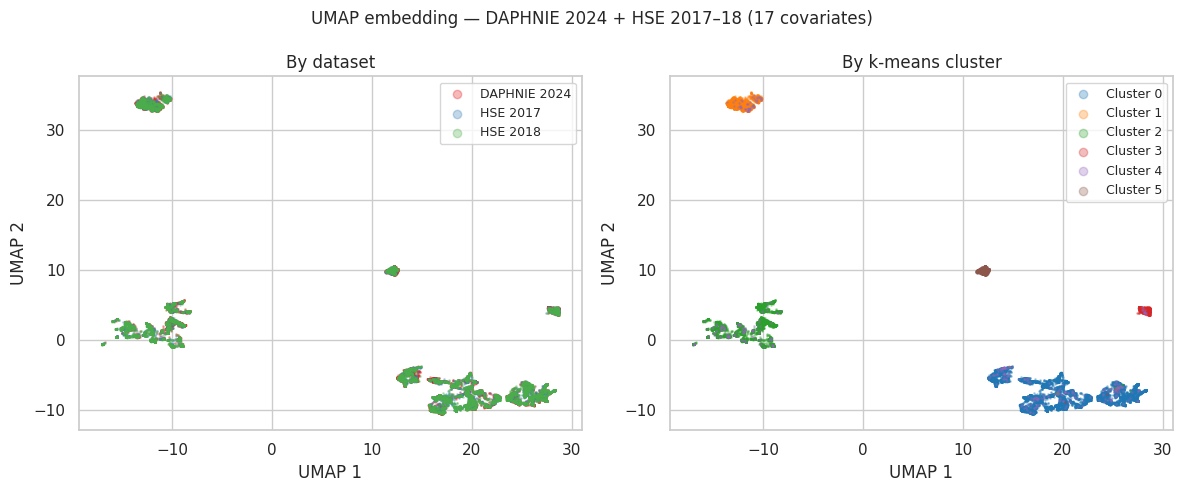

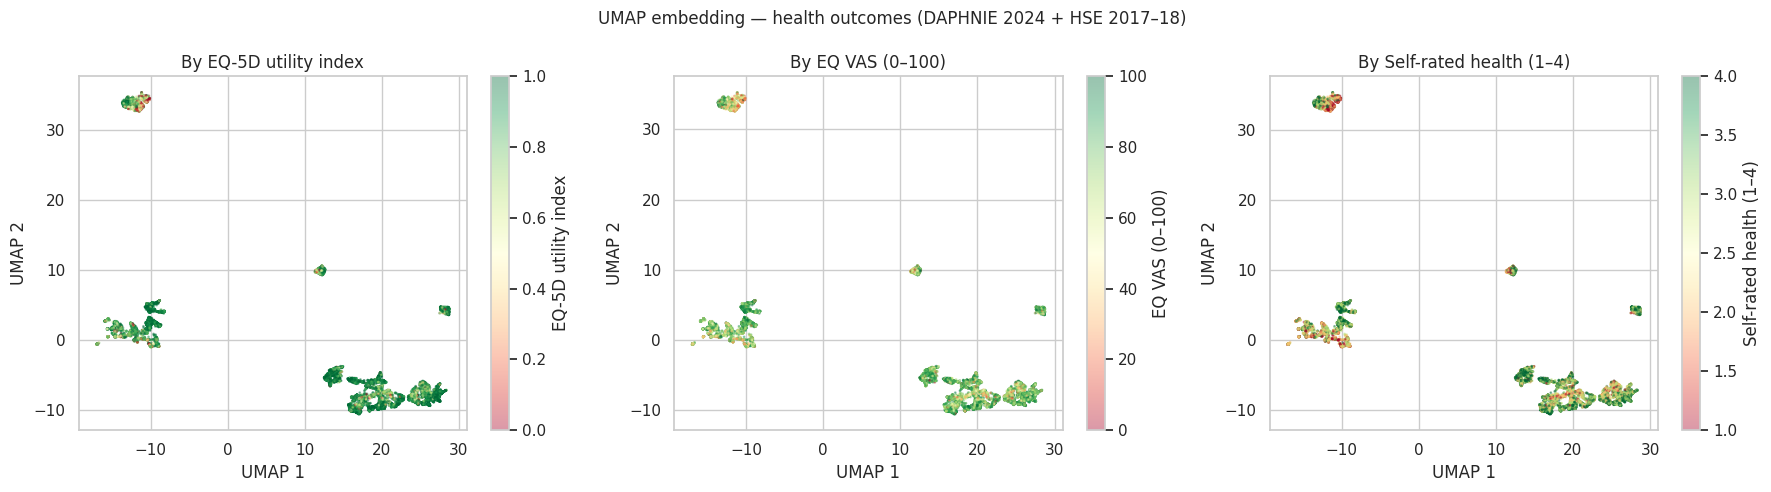

In [18]:
DATASET_COLOURS = {
    'DAPHNIE 2024': '#e41a1c',
    'HSE 2017':     '#377eb8',
    'HSE 2018':     '#4daf4a',
}

cluster_palette = sns.color_palette('tab10', n_colors=K_OPT)

# --- Figure 1: dataset membership and cluster assignment ---
fig1, axes1 = plt.subplots(1, 2, figsize=(12, 5))

for ds, grp in df_r.groupby('dataset'):
    axes1[0].scatter(grp['umap_1'], grp['umap_2'],
                     s=1, alpha=0.3, color=DATASET_COLOURS[ds],
                     label=ds, rasterized=True)
axes1[0].set_title('By dataset')
axes1[0].legend(markerscale=6, framealpha=0.8, fontsize=9)

for c in sorted(df_r['cluster'].unique()):
    grp = df_r[df_r['cluster'] == c]
    axes1[1].scatter(grp['umap_1'], grp['umap_2'],
                     s=1, alpha=0.3, color=cluster_palette[c],
                     label=f'Cluster {c}', rasterized=True)
axes1[1].set_title('By k-means cluster')
axes1[1].legend(markerscale=6, framealpha=0.8, fontsize=9)

for ax in axes1:
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

fig1.suptitle('UMAP embedding — DAPHNIE 2024 + HSE 2017–18 (17 covariates)', fontsize=12)
fig1.tight_layout()
fig1.savefig(PLOTS_PATH / 'umap_embedding.png', dpi=600, bbox_inches='tight')
plt.show()

# --- Figure 2: health outcomes overlaid on the embedding ---
# All three outcomes are coded higher = better health, so RdYlGn is consistent.
# EQvas is deferred to the full paper but included here for visual exploration.
outcome_specs = [
    ('EQ_index', 'EQ-5D utility index',   0,   1),
    ('EQvas',    'EQ VAS (0–100)',         0, 100),
    ('srh_2',      'Self-rated health (1–4)', 1,   4),
]

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, label, vmin, vmax) in zip(axes2, outcome_specs):
    valid = df_r[col].notna()
    sc = ax.scatter(df_r.loc[valid, 'umap_1'], df_r.loc[valid, 'umap_2'],
                    c=df_r.loc[valid, col], cmap='RdYlGn',
                    s=1, alpha=0.4, vmin=vmin, vmax=vmax, rasterized=True)
    plt.colorbar(sc, ax=ax, label=label)
    ax.set_title(f'By {label}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

fig2.suptitle('UMAP embedding — health outcomes (DAPHNIE 2024 + HSE 2017–18)', fontsize=12)
fig2.tight_layout()
fig2.savefig(PLOTS_PATH / 'umap_health_outcomes.png', dpi=600, bbox_inches='tight')
plt.show()

## 5. Cluster Profiles

### Sociodemographic profiles

Unweighted mean of each feature per cluster. Colours show the z-score across clusters;
cell annotations show raw means.

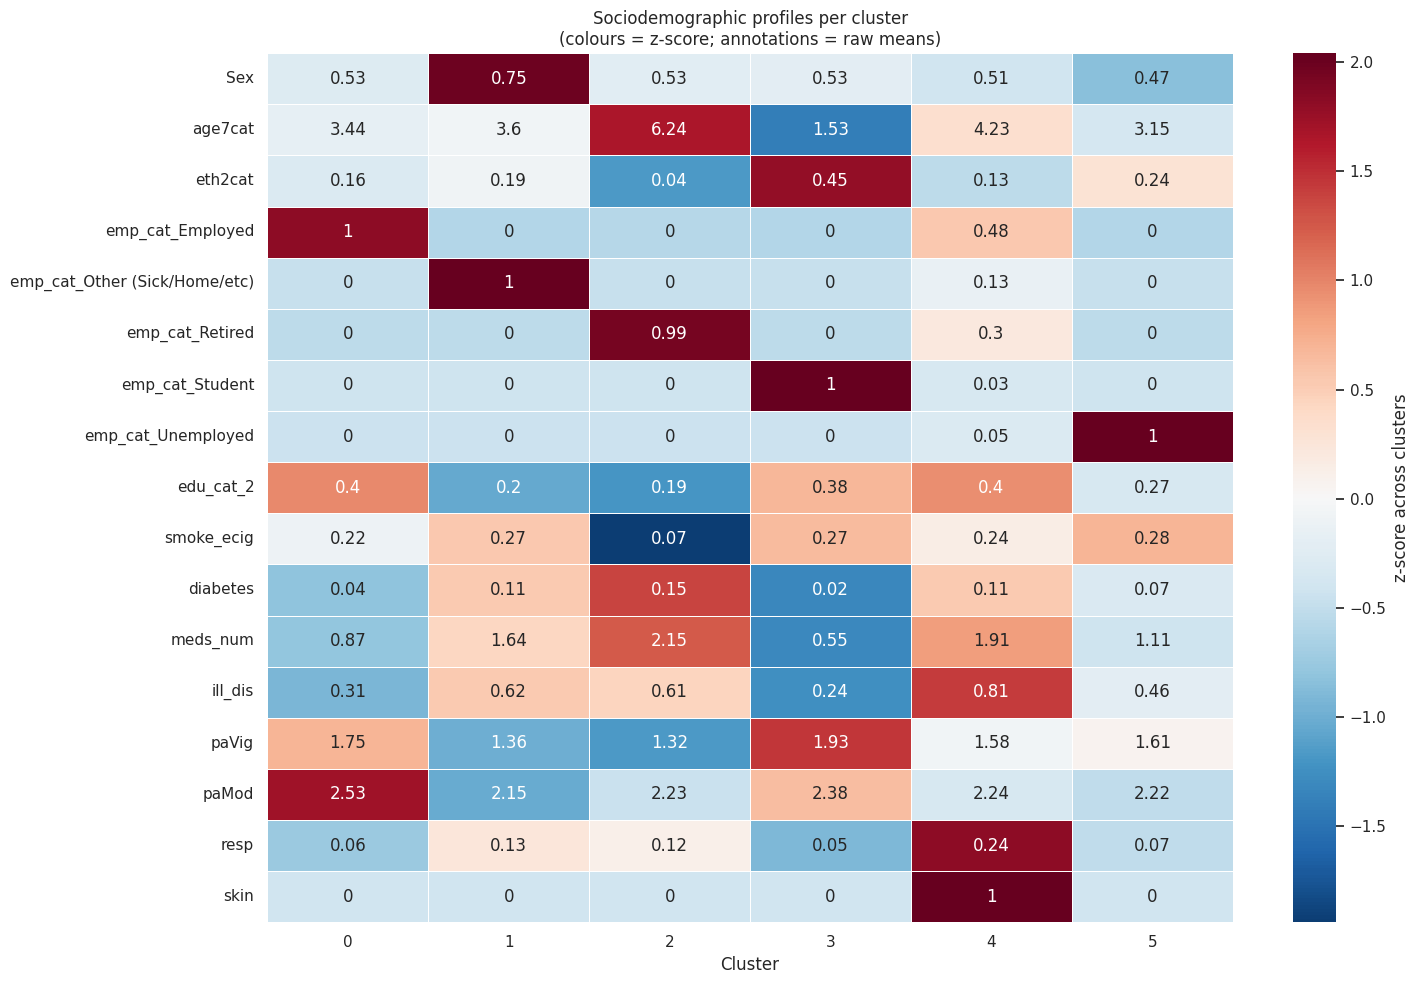

In [9]:
profile_raw = df_r.groupby('cluster')[ALL_FEATURES].mean()
profile_z   = (profile_raw - profile_raw.mean()) / profile_raw.std().replace(0, 1)

fig, ax = plt.subplots(figsize=(max(8, K_OPT * 2.5), 10))
sns.heatmap(profile_z.T,
            annot=profile_raw.T.round(2), fmt='g',
            cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.5,
            cbar_kws={'label': 'z-score across clusters'})
ax.set_xlabel('Cluster')
ax.set_ylabel('')
ax.set_title('Sociodemographic profiles per cluster\n(colours = z-score; annotations = raw means)')
plt.tight_layout()
plt.savefig(PLOTS_PATH / 'cluster_feature_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

### Health outcome profiles

Unweighted mean of each EQ-5D outcome and `srh` per cluster.

,MO5L,SC5L,UA5L,PD5L,AD5L,EQ_index,LSS_rs,srh
cluster,,,,,,,,
0,1.186,1.057,1.184,1.537,1.490,0.921,92.753,4.008
1,1.916,1.582,2.027,2.299,2.283,0.667,74.496,3.103
2,1.713,1.223,1.575,2.005,1.411,0.844,85.483,3.539
3,1.158,1.080,1.244,1.398,1.730,0.906,91.976,4.041
4,1.667,1.307,1.681,2.065,1.844,0.790,82.048,3.234
5,1.456,1.223,1.533,1.797,2.180,0.806,84.195,3.288


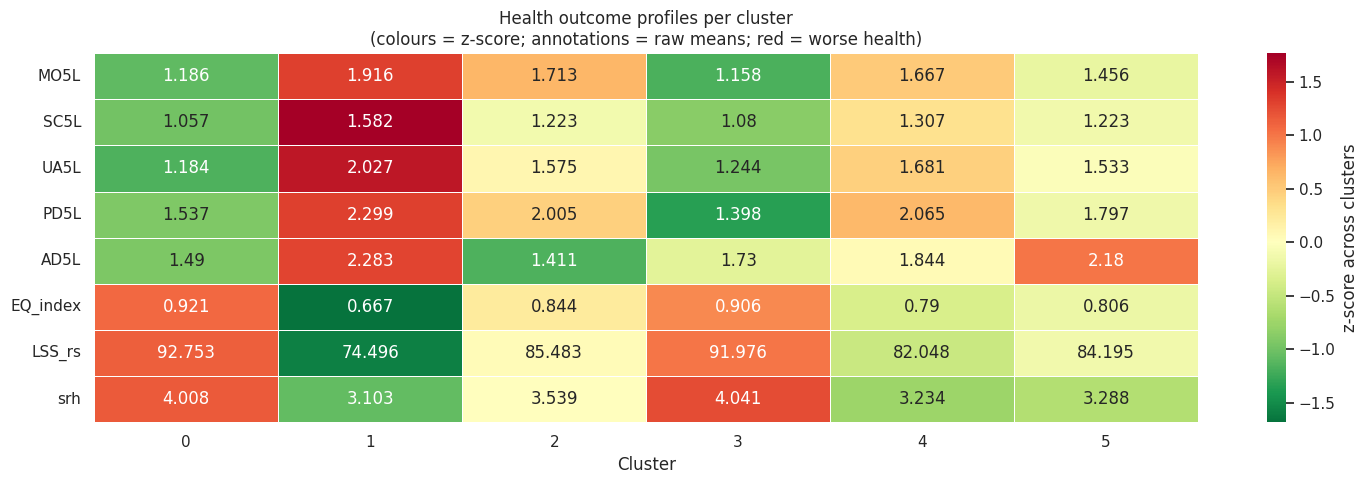

In [10]:
OUTCOMES = ['MO5L', 'SC5L', 'UA5L', 'PD5L', 'AD5L', 'EQ_index', 'LSS_rs', 'srh']
OUTCOMES  = [o for o in OUTCOMES if o in df_r.columns]

outcome_profile = df_r.groupby('cluster')[OUTCOMES].mean()
display(outcome_profile.round(3))

outcome_z = (outcome_profile - outcome_profile.mean()) / outcome_profile.std().replace(0, 1)

fig, ax = plt.subplots(figsize=(max(8, K_OPT * 2.5), 5))
sns.heatmap(outcome_z.T,
            annot=outcome_profile.T.round(3), fmt='g',
            cmap='RdYlGn_r', center=0, ax=ax,
            linewidths=0.5,
            cbar_kws={'label': 'z-score across clusters'})
ax.set_xlabel('Cluster')
ax.set_ylabel('')
ax.set_title('Health outcome profiles per cluster\n(colours = z-score; annotations = raw means; red = worse health)')
plt.tight_layout()
plt.savefig(PLOTS_PATH / 'cluster_outcome_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Cluster Composition by Dataset

Two views of the cluster × dataset cross-tabulation:

- **Left panel:** what share of each cluster comes from DAPHNIE 2024 vs HSE?
  Clusters dominated by DAPHNIE mark regions where the online panel is overrepresented.
- **Right panel:** how is each dataset distributed across clusters?
  Reveals systematic concentration of one dataset in particular health/SES subgroups.

A chi-squared test assesses whether cluster assignment is independent of dataset.

Cluster composition — % from each dataset (rows sum to 100%):


dataset,DAPHNIE 2024,HSE 2017,HSE 2018
cluster,,,
0,24.000,37.600,38.400
1,26.000,36.300,37.600
2,19.200,40.700,40.100
3,40.900,25.100,34.000
4,38.700,29.600,31.700
5,50.700,24.700,24.700



Dataset allocation across clusters — % of each dataset per cluster (cols sum to 100%):


dataset,DAPHNIE 2024,HSE 2017,HSE 2018
cluster,,,
0,51.500,53.900,54.000
1,12.000,11.200,11.400
2,20.100,28.500,27.500
3,5.700,2.300,3.100
4,3.100,1.600,1.700
5,7.600,2.500,2.400



Chi-squared (cluster independent of dataset): chi2=532.0, df=10, p=6.35e-108


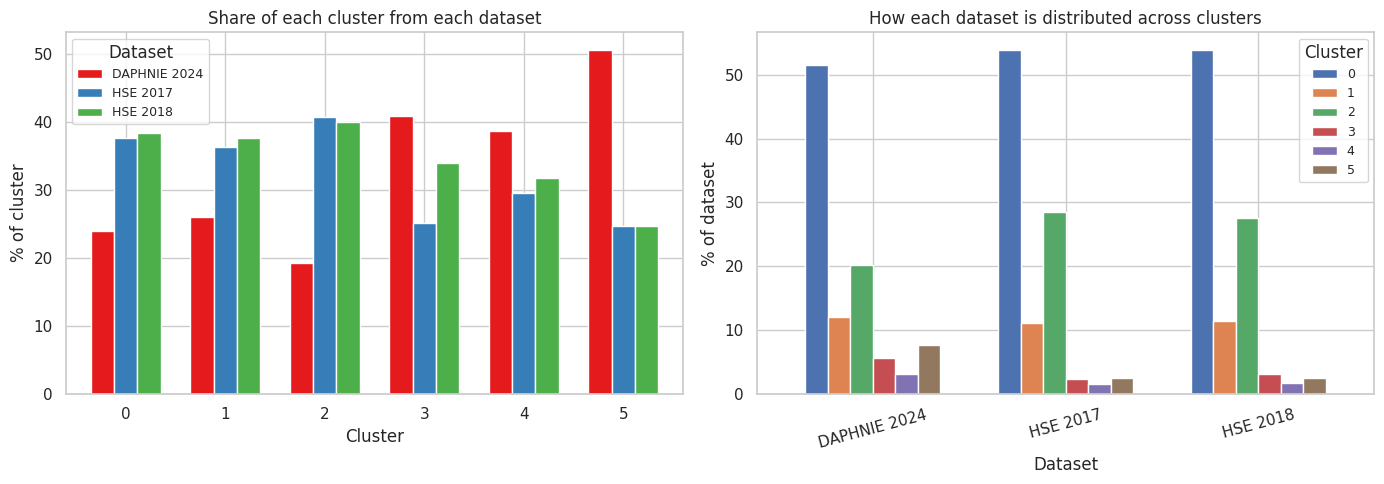

In [11]:
comp_n = (df_r.groupby(['cluster', 'dataset'])
          .size()
          .unstack(fill_value=0))

comp_pct_row = comp_n.div(comp_n.sum(axis=1), axis=0).mul(100)
print('Cluster composition — % from each dataset (rows sum to 100%):')
display(comp_pct_row.round(1))

comp_pct_col = comp_n.div(comp_n.sum(axis=0), axis=1).mul(100)
print('\nDataset allocation across clusters — % of each dataset per cluster (cols sum to 100%):')
display(comp_pct_col.round(1))

chi2_stat, p_chi, dof, _ = chi2_contingency(comp_n.values)
print(f'\nChi-squared (cluster independent of dataset): chi2={chi2_stat:.1f}, df={dof}, p={p_chi:.2e}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comp_pct_row.plot(kind='bar', ax=axes[0],
                  color=[DATASET_COLOURS[c] for c in comp_pct_row.columns],
                  edgecolor='white', width=0.7)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('% of cluster')
axes[0].set_title('Share of each cluster from each dataset')
axes[0].legend(title='Dataset', fontsize=9)
axes[0].tick_params(axis='x', rotation=0)

comp_pct_col.T.plot(kind='bar', ax=axes[1], edgecolor='white', width=0.7)
axes[1].set_xlabel('Dataset')
axes[1].set_ylabel('% of dataset')
axes[1].set_title('How each dataset is distributed across clusters')
axes[1].legend(title='Cluster', fontsize=9)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(PLOTS_PATH / 'cluster_composition.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Link to Norm Derivation (Aim 2): Density Ratio Weights per Cluster

The plain LR density ratio from notebook 04 is re-estimated here (self-contained, same
architecture and predictor set) to connect the cluster structure to the reweighting used
in norm derivation.

$$w(x) = \frac{\hat{P}(\text{HSE} \mid x)}{1 - \hat{P}(\text{HSE} \mid x)}$$

- $w > 1$: this observation looks more like HSE than DAPHNIE → **underrepresented** in
  the online panel; the reweighting upscales these observations when deriving norms.
- $w < 1$: the observation is more characteristic of DAPHNIE → **overrepresented**;
  the reweighting downscales.

Mapping the mean cluster weight back to the cluster profiles from Section 5 gives a
mechanistic account of *which subgroups* the norm derivation correction is acting on.

Weight range (clipped + normalised): 0.026 – 4.997
ESS: 2985 / 5237 (57.0%)

Mean density ratio weight per cluster (DAPHNIE 2024 observations):
  w > 1: underrepresented in DAPHNIE  |  w < 1: overrepresented


,mean,median,std
cluster,,,
0,1.062,0.786,0.871
1,0.988,0.815,0.786
2,1.292,1.058,0.962
3,0.573,0.397,0.631
4,0.512,0.369,0.460
5,0.346,0.290,0.271


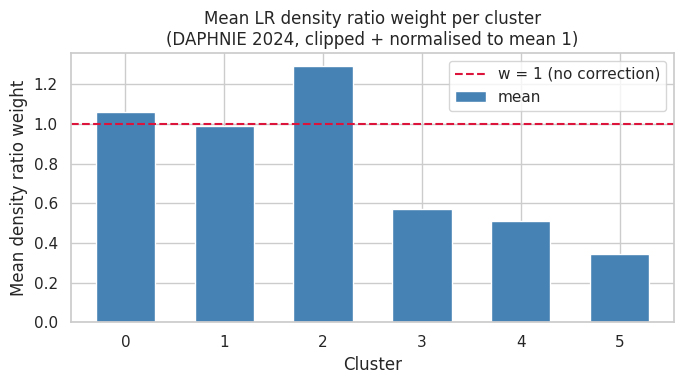

In [12]:
df_r['is_hse'] = df_r['dataset'].isin(['HSE 2017', 'HSE 2018']).astype(int)

lr_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('lr',      LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
])
lr_pipe.fit(df_r[ALL_FEATURES], df_r['is_hse'])

p_hat = lr_pipe.predict_proba(df_r[ALL_FEATURES])[:, 1]
p_hat = np.clip(p_hat, 1e-6, 1 - 1e-6)
w_raw = p_hat / (1 - p_hat)

daphnie_mask = df_r['dataset'] == 'DAPHNIE 2024'
w_d      = w_raw[daphnie_mask.values]
clip_val = np.percentile(w_d, 99)
w_norm   = np.minimum(w_d, clip_val)
w_norm   = w_norm / w_norm.mean()

df_r['w_lr'] = np.nan
df_r.loc[daphnie_mask, 'w_lr'] = w_norm

ess = w_norm.sum() ** 2 / (w_norm ** 2).sum()
n_d = int(daphnie_mask.sum())
print(f'Weight range (clipped + normalised): {w_norm.min():.3f} – {w_norm.max():.3f}')
print(f'ESS: {ess:.0f} / {n_d} ({ess / n_d * 100:.1f}%)')

w_summary = df_r[daphnie_mask].groupby('cluster')['w_lr'].agg(['mean', 'median', 'std'])
print('\nMean density ratio weight per cluster (DAPHNIE 2024 observations):')
print('  w > 1: underrepresented in DAPHNIE  |  w < 1: overrepresented')
display(w_summary.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
w_summary['mean'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white', width=0.6)
ax.axhline(1.0, color='crimson', linestyle='--', linewidth=1.5, label='w = 1 (no correction)')
ax.set_xlabel('Cluster')
ax.set_ylabel('Mean density ratio weight')
ax.set_title('Mean LR density ratio weight per cluster\n(DAPHNIE 2024, clipped + normalised to mean 1)')
ax.legend()
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(PLOTS_PATH / 'cluster_density_ratio_weights.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary

### Cluster characterisation

Six clusters emerge from k-means on the standardised 17-variable feature set (peak silhouette = 0.257 at $k = 6$; chi²-test of independence: $p \approx 10^{-108}$). The silhouette score is modest — typical for health survey data where respondents lie on a continuum rather than forming discrete types — but the dataset-cluster association is unambiguous.

| Cluster | $n$ | % DAPHNIE | Mean $w(x)$ | EQ_index | AD5L | Interpretation |
|---|---|---|---|---|---|---|
| 0 | 11,236 | 24% | 1.06 | 0.921 | 1.49 | Healthy majority; near-representative |
| 1 | 2,413 | 26% | 0.99 | 0.667 | 2.28 | Severe overall morbidity; balanced composition |
| 2 | 5,488 | 19% | 1.29 | 0.844 | 1.41 | Moderate health; HSE-enriched |
| 3 | 724 | 41% | 0.57 | 0.906 | 1.73 | Good physical health, elevated anxiety/depression; DAPHNIE-enriched |
| 4 | 419 | 39% | 0.51 | 0.790 | 1.84 | Moderate health, high anxiety/depression; DAPHNIE-enriched |
| 5 | 787 | 51% | 0.35 | 0.806 | 2.18 | Anxiety/depression dominant; most DAPHNIE-enriched |

### Two structural patterns

**Pattern 1 — Over-recruitment of anxiety/depression-dominant subgroups (clusters 3, 4, 5).** All three are DAPHNIE-enriched (39–51%) and share a distinctive profile: anxiety/depression is elevated *relative to their physical health*. Clusters 3 and 5 are the clearest examples — EQ_index $\geq$ 0.81 (not severely ill physically) but AD5L well above the sample average. These respondents are systematically over-recruited by health-focused online panels, likely due to self-selection of health-engaged individuals. Cluster 5 alone (51% DAPHNIE, $w = 0.35$) requires roughly three-fold downscaling; it is the primary driver of the AD5L gap documented in notebook 04 (54% vs 32% any problem after adjustment).

**Pattern 2 — Under-recruitment of a moderate-health subgroup (cluster 2).** Cluster 2 (19% DAPHNIE, $w = 1.29$) has moderate but non-severe health across all dimensions. The online panel consistently fails to recruit this profile — likely moderately healthy working-age individuals who are less motivated to join or remain in health-focused panels. The density ratio upscales these observations.

### Physical morbidity is not the driver

Cluster 1 — the worst health cluster by every dimension (EQ_index 0.667, MO5L 1.92, UA5L 2.03, PD5L 2.30) — is near-balanced at 26% DAPHNIE, close to the overall DAPHNIE share (~25%). DAPHNIE 2024 recruits severely ill individuals in proportion. The Aim 2 norm gap is not explained by an absence of sick people from the panel; it is explained by the *composition* of mental health burden relative to physical health within DAPHNIE-enriched clusters.

### Connection to Aim 2

The density ratio weights (Section 7) map cleanly onto this structure. The adjustment in notebook 04 downscales clusters 3–5 and upscales cluster 2, pulling DAPHNIE's estimated health profile towards worse anxiety/depression values and better physical dimension values relative to the raw panel estimates. The net effect widens rather than closes the overall gap: correcting for the observable overrepresentation of health-engaged subgroups reveals that even after demographic and morbidity adjustment, panel respondents report substantially worse mental health than the random-sample reference.

## 9. Sensitivity Analysis: UMAP with Gower Distance

### Rationale

The UMAP in Section 4 uses **Hamming distance**, which measures the proportion of mismatched values across all 17 features. This is exact for binary indicators (13 of the 17 variables: `Sex`, employment dummies, `eth2cat`, `edu_cat_2`, `smoke_ecig`, `diabetes`, `ill_dis`, `resp`, `skin`) but ignores the *ordering* of the four ordinal/continuous variables:

| Variable | Scale | Hamming treatment | Gower treatment |
|---|---|---|---|
| `age7cat` | 1–7 | any mismatch = 1 unit | $\|x_i - x_j\| / 6$ |
| `meds_num` | 0, 1, 2, … | any mismatch = 1 unit | $\|x_i - x_j\| / \text{range}$ |
| `paVig` | 1–3 | any mismatch = 1 unit | $\|x_i - x_j\| / 2$ |
| `paMod` | 1–4 | any mismatch = 1 unit | $\|x_i - x_j\| / 3$ |

Under Hamming, a 25-year-old and a 75-year-old are as distant as a 25-year-old and a 30-year-old. **Gower distance** corrects this: for each feature $j$ and pair $(i, k)$,
$$d_j(i,k) = \begin{cases} \mathbf{1}[x_{ij} \neq x_{kj}] & \text{binary} \\ |x_{ij} - x_{kj}| \,/\, \mathrm{range}_j & \text{ordinal/continuous} \end{cases}$$
and the overall distance is the average across all $p$ features, always in $[0, 1]$.

### Computational constraint and solution

Computing the full pairwise Gower matrix for $n = 21{,}067$ requires storing a $21{,}067 \times 21{,}067$ matrix ($\approx 1.7$ GB in float32) and $\approx 3.8$ billion floating-point operations — prohibitive in a notebook.

**Solution: stratified subsample.** A proportional subsample of $n = 5{,}000$ reduces the matrix to $\approx 100$ MB, computable via vectorised NumPy in seconds. The subsample preserves the original dataset proportions (DAPHNIE 2024 ≈ 25 %, HSE 2017 ≈ 37 %, HSE 2018 ≈ 38 %), so the embedding can still be evaluated for the same dataset-level and cluster-level patterns as Section 4.

UMAP is fitted on the precomputed distance matrix (`metric='precomputed'`). The resulting Gower embedding is shown alongside the equivalent Hamming subsample (i.e. the same rows extracted from the full embedding in Section 4).

In [13]:
import time

# Classify each feature as binary (cat_mask=True) or ordinal/continuous (False)
# for the Gower distance computation
BINARY_FEATURES = [
    "Sex", "eth2cat",
    "emp_cat_Employed", "emp_cat_Other (Sick/Home/etc)",
    "emp_cat_Retired", "emp_cat_Student", "emp_cat_Unemployed",
    "edu_cat_2", "smoke_ecig", "diabetes", "ill_dis", "resp", "skin",
]
cat_mask = np.array([f in BINARY_FEATURES for f in ALL_FEATURES])
print("Variable type assignments:")
for f, is_cat in zip(ALL_FEATURES, cat_mask):
    print(f"  {'binary  ' if is_cat else 'ordinal '} {f}")


def gower_matrix(X, cat_mask):
    """
    Gower distance matrix for an array with mixed binary and ordinal variables.
    X     : (n, p) float array, no NaN (apply imputation beforehand).
    cat_mask : bool (p,), True = binary/nominal, False = ordinal/continuous.
    Returns  : (n, n) float32 distance matrix with values in [0, 1].
    """
    n, p = X.shape
    D = np.zeros((n, n), dtype=np.float32)
    n_active = 0
    for j in range(p):
        col = X[:, j].astype(np.float32)
        if cat_mask[j]:
            d = (col[:, None] != col[None, :]).astype(np.float32)
        else:
            r = col.max() - col.min()
            if r == 0:
                continue        # zero-variance feature contributes nothing
            d = np.abs(col[:, None] - col[None, :]) / r
        D += d
        n_active += 1
    return D / n_active


# Stratified subsample proportional to dataset sizes
SUBSAMPLE_N = 5_000
rng = np.random.default_rng(42)

props   = df_r['dataset'].value_counts() / len(df_r)
n_per_ds = (props * SUBSAMPLE_N).round().astype(int)
n_per_ds.iloc[0] += SUBSAMPLE_N - n_per_ds.sum()   # absorb rounding remainder

sub_idx = []
for ds, n in n_per_ds.items():
    positions = df_r.index[df_r['dataset'] == ds].tolist()
    sub_idx.extend(rng.choice(positions, size=n, replace=False).tolist())
sub_idx = np.sort(sub_idx)

# X_imp: raw imputed values (before StandardScaler) — Gower handles scale internally
X_sub  = X_imp[sub_idx]
df_sub = df_r.iloc[sub_idx].copy().reset_index(drop=True)

print(f"\nSubsample (n={len(sub_idx):,}):")
print(df_sub['dataset'].value_counts().to_string())
print(f"\nGower matrix will be {len(sub_idx)} × {len(sub_idx)} "
      f"≈ {len(sub_idx)**2 * 4 / 1e6:.0f} MB (float32)")

Variable type assignments:
  binary   Sex
  ordinal  age7cat
  binary   eth2cat
  binary   emp_cat_Employed
  binary   emp_cat_Other (Sick/Home/etc)
  binary   emp_cat_Retired
  binary   emp_cat_Student
  binary   emp_cat_Unemployed
  binary   edu_cat_2
  binary   smoke_ecig
  binary   diabetes
  ordinal  meds_num
  binary   ill_dis
  ordinal  paVig
  ordinal  paMod
  binary   resp
  binary   skin

Subsample (n=5,000):
dataset
HSE 2018        1896
HSE 2017        1861
DAPHNIE 2024    1243

Gower matrix will be 5000 × 5000 ≈ 100 MB (float32)


Computing Gower distance matrix...
Done in 1.6s  |  shape: (5000, 5000)  |  distance range: [0.000, 0.824]


/home/luisggon/.cache/pypoetry/virtualenvs/euroqol-1goflkTH-py3.12/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")


UMAP (Gower) fitted in 14.4s


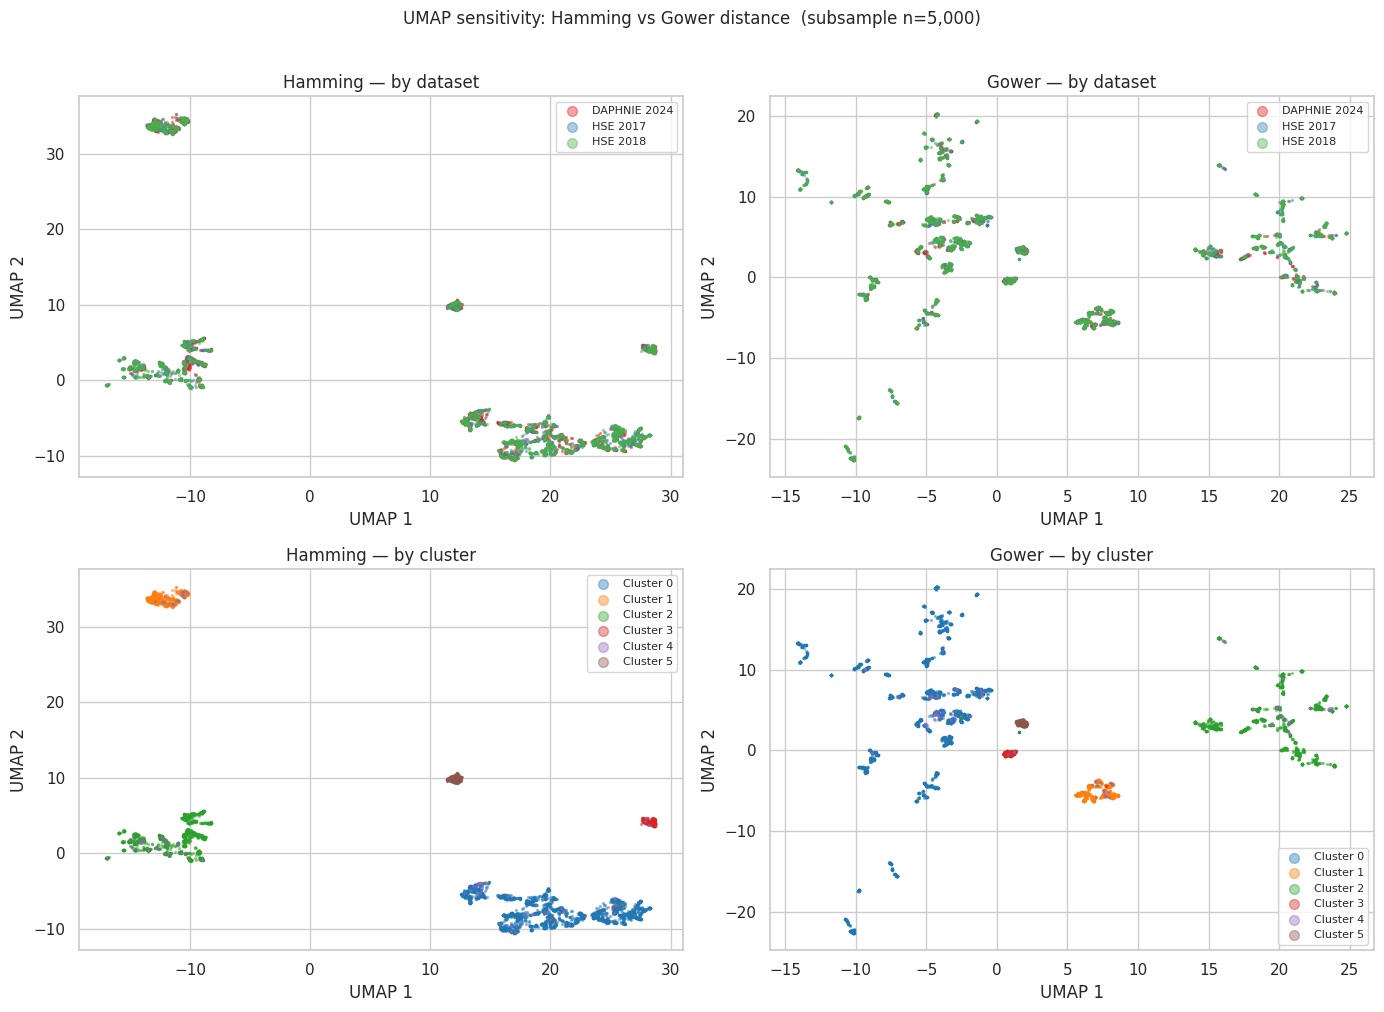

In [14]:
print("Computing Gower distance matrix...")
t0 = time.time()
D_gower = gower_matrix(X_sub, cat_mask)
np.fill_diagonal(D_gower, 0.0)   # ensure exact zeros on diagonal
print(f"Done in {time.time()-t0:.1f}s  |  shape: {D_gower.shape}  |  "
      f"distance range: [{D_gower.min():.3f}, {D_gower.max():.3f}]")

reducer_gower = umap.UMAP(
    n_neighbors=50, min_dist=0.1, n_components=2,
    random_state=42, n_jobs=1, metric='precomputed'
)
t0 = time.time()
emb_gower = reducer_gower.fit_transform(D_gower)
print(f"UMAP (Gower) fitted in {time.time()-t0:.1f}s")

df_sub[['umap_g1', 'umap_g2']] = emb_gower
df_sub[['umap_h1', 'umap_h2']] = embedding[sub_idx]   # main Hamming embedding, same rows

# 2×2 comparison: rows = distance metric, cols = colouring variable
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, coords, title in [
    (axes[0, 0], ('umap_h1', 'umap_h2'), 'Hamming — by dataset'),
    (axes[0, 1], ('umap_g1', 'umap_g2'), 'Gower — by dataset'),
]:
    for ds, grp in df_sub.groupby('dataset'):
        ax.scatter(grp[coords[0]], grp[coords[1]],
                   s=2, alpha=0.4, color=DATASET_COLOURS[ds], label=ds, rasterized=True)
    ax.set_title(title)
    ax.legend(markerscale=5, fontsize=8)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

cluster_pal = sns.color_palette('tab10', n_colors=K_OPT)
for ax, coords, title in [
    (axes[1, 0], ('umap_h1', 'umap_h2'), 'Hamming — by cluster'),
    (axes[1, 1], ('umap_g1', 'umap_g2'), 'Gower — by cluster'),
]:
    for c in sorted(df_sub['cluster'].unique()):
        grp = df_sub[df_sub['cluster'] == c]
        ax.scatter(grp[coords[0]], grp[coords[1]],
                   s=2, alpha=0.4, color=cluster_pal[c], label=f'Cluster {c}', rasterized=True)
    ax.set_title(title)
    ax.legend(markerscale=5, fontsize=8)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

plt.suptitle(
    f'UMAP sensitivity: Hamming vs Gower distance  (subsample n={len(sub_idx):,})',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(PLOTS_PATH / 'umap_gower_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()